# Travel Reimbursement Approval Agent — Prototype

**Candidate assignment submission** · GenAI / Agentic AI Developer role

This notebook is a **runnable, top-to-bottom** prototype of an AI-assisted agent that evaluates
employee travel reimbursement claims against a company policy and returns a structured,
explainable recommendation (`APPROVE` / `PARTIAL_APPROVE` / `REJECT` / `MANUAL_REVIEW`).

---

## README — Setup & How to Run

**Requirements:** Python 3.10+, `pandas`, `matplotlib`. No paid services required.

```bash
pip install pandas matplotlib openai anthropic   # anthropic/openai are OPTIONAL
```

**Environment variables (optional — the agent works fully without them):**

| Variable | Purpose |
|---|---|
| `OPENAI_API_KEY` | If set, the agent uses a real OpenAI LLM call to generate the natural-language explanation & confidence narrative. |
| `ANTHROPIC_API_KEY` | If set (and `OPENAI_API_KEY` is not), the agent uses Claude instead. |
| *(neither set)* | The agent automatically falls back to a **local, template-based "simulated LLM" reasoning layer** so the whole notebook still runs for free, offline, deterministically, and reproducibly during review. |

**How to run:** `Run All`. The notebook will:
1. Load the policy (Appendix A) and the 5 sample claims (Appendix B) — both embedded as data, exactly as provided in the assignment, nothing invented.
2. Run each claim through the **Agent Orchestrator**, which decides which tools to call, in what order, and how to combine their results.
3. Print a per-claim **reasoning / tool-call audit trail**.
4. Emit the final **structured JSON array** (the graded deliverable) in the last code cell.
5. Render a small **results dashboard** (also saved as `UI_SS_1.png`).

**Key design choice (explained in full in "Design Notes & Reasoning" at the bottom):**
Money-affecting calculations (per-diem caps, receipt rules, approval tiers) are done by
**deterministic Python tools**, not by asking an LLM to do arithmetic. The LLM's job is
**orchestration reasoning and explanation generation** — the layer where GenAI adds real value
without risking hallucinated numbers in a financial workflow.


In [1]:

import os, json, math, re
from datetime import date, datetime
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Any, Optional

import pandas as pd
import matplotlib.pyplot as plt

# ---- LLM availability detection (used later by the Agent Orchestrator) ----
USE_OPENAI = bool(os.environ.get("OPENAI_API_KEY"))
USE_ANTHROPIC = (not USE_OPENAI) and bool(os.environ.get("ANTHROPIC_API_KEY"))
LLM_MODE = "openai" if USE_OPENAI else ("anthropic" if USE_ANTHROPIC else "local-simulated")
print(f"LLM mode for this run: {LLM_MODE}")


LLM mode for this run: local-simulated


## 1. Context Grounding — Policy Knowledge Base (Appendix A)

The policy is loaded as **structured data with stable rule IDs** (as given in the assignment),
so the agent can retrieve and cite exact rules (`POL-*`) instead of relying on free-text search.
This is the "context grounding" step required before any decision is made — a lightweight,
deterministic stand-in for a RAG index, appropriate for a ~15-rule policy document (a full
vector DB would be over-engineering for this scope; see Design Notes).


In [2]:

POLICY = {
    "POL-CAT-01": {
        "title": "Eligible categories",
        "text": "Reimbursable when incurred for a documented business purpose: airfare (economy only), "
                 "lodging, meals (per-diem), ground transport, conference/registration fees.",
        "eligible_categories": ["airfare", "lodging", "meals", "ground_transport", "conference_fees"],
    },
    "POL-CAT-02": {
        "title": "Ineligible items",
        "text": "Never reimbursable: alcohol/minibar, spa/gym/personal entertainment, in-room movies, "
                 "personal shopping/gifts, traffic fines/penalties, any personal expense.",
        "ineligible_categories": ["alcohol", "minibar", "spa", "gym", "entertainment",
                                    "movies", "personal_shopping", "gifts", "fines", "personal"],
    },
    "POL-PD-01": {"title": "Meals per-diem", "category": "meals", "daily_cap": 75},
    "POL-PD-02": {"title": "Lodging per-night cap", "category": "lodging", "nightly_cap": 200},
    "POL-PD-03": {"title": "Ground transport per-diem", "category": "ground_transport", "daily_cap": 50},
    "POL-AIR-01": {
        "title": "Airfare class",
        "text": "Only economy airfare is reimbursable. Business/first class is a policy exception -> Manual Review (not auto-deducted).",
    },
    "POL-RCT-01": {
        "title": "Receipt required above $25",
        "text": "Any line item > $25 requires an itemized receipt. Airfare & lodging ALWAYS require a receipt regardless of amount.",
        "threshold": 25,
        "always_required_categories": ["airfare", "lodging"],
    },
    "POL-RCT-02": {
        "title": "Missing receipt handling",
        "text": "Missing required receipt -> NOT auto-rejected -> routed to Manual Review.",
    },
    "POL-APR-01": {"title": "Auto-approve tier", "max_total": 500, "tier": "agent-auto"},
    "POL-APR-02": {"title": "Manager tier", "min_total": 500, "max_total": 2000, "tier": "manager"},
    "POL-APR-03": {"title": "Director / Manual-Review tier", "min_total": 2000, "tier": "manual-review"},
    "POL-TIME-01": {"title": "Submission window", "text": "Claims must be submitted within 30 days of the expense date. Late -> Manual Review.", "window_days": 30},
}

def policy_lookup(rule_id: str) -> Dict[str, Any]:
    '''TOOL 1: Retrieve a specific policy rule by its stable ID (grounding/citation tool).'''
    return {"rule_id": rule_id, **POLICY.get(rule_id, {"error": "unknown rule id"})}

print(f"Loaded {len(POLICY)} policy rules:", ", ".join(POLICY.keys()))


Loaded 12 policy rules: POL-CAT-01, POL-CAT-02, POL-PD-01, POL-PD-02, POL-PD-03, POL-AIR-01, POL-RCT-01, POL-RCT-02, POL-APR-01, POL-APR-02, POL-APR-03, POL-TIME-01


## 2. Claim Intake (Appendix B — the 5 provided sample claims, unmodified)

In [3]:

CLAIMS = [
    {
        "claim_id": "CLM-001",
        "employee": "A. Rivera",
        "trip_start": "2026-06-10", "trip_end": "2026-06-12", "submitted": "2026-06-20",
        "purpose": "Attend 2-day industry conference (business)",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt": True, "class": "economy", "days": None},
            {"category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00, "receipt": True, "nights": 2},
            {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt": True, "days": 3},
            {"category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt": True},
        ],
    },
    {
        "claim_id": "CLM-002",
        "employee": "B. Osei",
        "trip_start": "2026-06-14", "trip_end": "2026-06-15", "submitted": "2026-06-25",
        "purpose": "Weekend hotel stay",
        "items": [
            {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt": True},
            {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt": True},
        ],
    },
    {
        "claim_id": "CLM-003",
        "employee": "C. Nakamura",
        "trip_start": "2026-06-08", "trip_end": "2026-06-10", "submitted": "2026-06-22",
        "purpose": "Client site visit (business)",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt": True, "class": "economy"},
            {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt": True, "nights": 2},
            {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt": True, "days": 2},
        ],
    },
    {
        "claim_id": "CLM-004",
        "employee": "D. Fischer",
        "trip_start": "2026-06-16", "trip_end": "2026-06-18", "submitted": "2026-06-28",
        "purpose": "International vendor negotiation (business)",
        "items": [
            {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt": True, "class": "business"},
            {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt": False, "nights": 3},
        ],
    },
    {
        "claim_id": "CLM-005",
        "employee": "E. Haddad",
        "trip_start": "2026-06-11", "trip_end": "2026-06-11", "submitted": "2026-06-24",
        "purpose": "Client dinner / business development",
        "items": [
            {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt": False, "days": 1},
        ],
    },
]

df_intake = pd.json_normalize(CLAIMS, "items", ["claim_id", "employee", "purpose"])
df_intake


,category,description,amount,receipt,class,days,nights,claim_id,employee,purpose
0,airfare,Round-trip economy airfare,420.0,True,economy,NaN,NaN,CLM-001,A. Rivera,Attend 2-day industry conference (business)
1,lodging,"Hotel, 2 nights @ $180",360.0,True,NaN,NaN,2.0,CLM-001,A. Rivera,Attend 2-day industry conference (business)
2,meals,"Meals, 3 days @ ~$60/day",180.0,True,NaN,3.0,NaN,CLM-001,A. Rivera,Attend 2-day industry conference (business)
3,conference_fees,Conference registration,150.0,True,NaN,NaN,NaN,CLM-001,A. Rivera,Attend 2-day industry conference (business)
4,spa,Hotel spa package,300.0,True,NaN,NaN,NaN,CLM-002,B. Osei,Weekend hotel stay
5,minibar,In-room minibar,80.0,True,NaN,NaN,NaN,CLM-002,B. Osei,Weekend hotel stay
6,airfare,Round-trip economy airfare,300.0,True,economy,NaN,NaN,CLM-003,C. Nakamura,Client site visit (business)
7,lodging,"Hotel, 2 nights @ $250",500.0,True,NaN,NaN,2.0,CLM-003,C. Nakamura,Client site visit (business)
8,meals,"Meals, 2 days @ $70/day",140.0,True,NaN,2.0,NaN,CLM-003,C. Nakamura,Client site visit (business)
9,airfare,Business-class international airfare,2400.0,True,business,NaN,NaN,CLM-004,D. Fischer,International vendor negotiation (business)


## 3. Tools / Functions

At least two are required; this prototype implements **five** small, single-purpose, testable
tools. Each returns a structured dict so the orchestrator (and, in real-LLM mode, the LLM
itself via function-calling) can combine their outputs programmatically.

| Tool | Purpose |
|---|---|
| `policy_lookup` | Retrieve a policy rule by ID (defined above — grounding) |
| `receipt_completeness_check` | Flags line items missing a required receipt |
| `per_diem_limit_checker` | Applies POL-PD-01/02/03 caps, computes deductions |
| `duplicate_detector` | Flags a claim as a possible duplicate of a prior submission |
| `approval_threshold_check` | Applies POL-APR-01/02/03 to the net reimbursable total |
| `output_validator` | Validates the final JSON object against the required schema before it's emitted |


In [4]:

def receipt_completeness_check(claim: Dict) -> Dict[str, Any]:
    '''TOOL 2: Check every line item against POL-RCT-01 / POL-RCT-02.'''
    missing = []
    for item in claim["items"]:
        needs_receipt = (
            item["amount"] > POLICY["POL-RCT-01"]["threshold"]
            or item["category"] in POLICY["POL-RCT-01"]["always_required_categories"]
        )
        if needs_receipt and not item.get("receipt", False):
            missing.append(f'{item["category"]} receipt (${item["amount"]:.2f}: "{item["description"]}")')
    return {"tool": "receipt_completeness_check", "missing_docs": missing,
            "policy_refs": ["POL-RCT-01", "POL-RCT-02"] if missing else ["POL-RCT-01"]}


def per_diem_limit_checker(claim: Dict) -> Dict[str, Any]:
    '''TOOL 3: Apply category eligibility + per-diem/per-night caps (POL-CAT-02, POL-PD-01/02/03, POL-AIR-01).'''
    line_results, refs = [], set()
    for item in claim["items"]:
        cat, amt = item["category"], item["amount"]
        entry = {"category": cat, "amount": amt, "eligible": True, "reimbursable": amt,
                  "deducted": 0.0, "flag": None}

        if cat in POLICY["POL-CAT-02"]["ineligible_categories"]:
            entry.update(eligible=False, reimbursable=0.0, deducted=amt, flag="ineligible_category")
            refs.add("POL-CAT-02")

        elif cat == "airfare" and item.get("class") == "business":
            entry.update(reimbursable=0.0, deducted=0.0, flag="manual_review_airfare_class")
            refs.add("POL-AIR-01")

        elif cat == "meals":
            cap = POLICY["POL-PD-01"]["daily_cap"] * (item.get("days") or 1)
            if amt > cap:
                entry.update(reimbursable=cap, deducted=round(amt - cap, 2), flag="over_per_diem")
                refs.add("POL-PD-01")

        elif cat == "lodging":
            cap = POLICY["POL-PD-02"]["nightly_cap"] * (item.get("nights") or 1)
            if amt > cap:
                entry.update(reimbursable=cap, deducted=round(amt - cap, 2), flag="over_per_diem")
                refs.add("POL-PD-02")

        elif cat == "ground_transport":
            cap = POLICY["POL-PD-03"]["daily_cap"] * (item.get("days") or 1)
            if amt > cap:
                entry.update(reimbursable=cap, deducted=round(amt - cap, 2), flag="over_per_diem")
                refs.add("POL-PD-03")

        line_results.append(entry)

    return {"tool": "per_diem_limit_checker", "line_results": line_results, "policy_refs": sorted(refs)}


_SEEN_CLAIM_SIGNATURES = set()  # simple in-memory ledger for this run

def duplicate_detector(claim: Dict) -> Dict[str, Any]:
    '''TOOL 4: Flag possible duplicate submissions (same employee+trip dates+total).'''
    total = sum(i["amount"] for i in claim["items"])
    sig = (claim["employee"], claim["trip_start"], claim["trip_end"], round(total, 2))
    is_dup = sig in _SEEN_CLAIM_SIGNATURES
    _SEEN_CLAIM_SIGNATURES.add(sig)
    return {"tool": "duplicate_detector", "is_duplicate": is_dup}


def approval_threshold_check(net_reimbursable: float) -> Dict[str, Any]:
    '''TOOL 5: Apply POL-APR-01/02/03 to the net (post-deduction) reimbursable amount.'''
    if net_reimbursable > POLICY["POL-APR-03"]["min_total"]:
        tier, refs = "manual-review", ["POL-APR-03"]
    elif net_reimbursable > POLICY["POL-APR-01"]["max_total"]:
        tier, refs = "manager", ["POL-APR-02"]
    else:
        tier, refs = "agent-auto", ["POL-APR-01"]
    return {"tool": "approval_threshold_check", "tier": tier, "policy_refs": refs}


def timeliness_check(claim: Dict) -> Dict[str, Any]:
    '''Bonus tool: POL-TIME-01 — flag late submissions (>30 days after trip end).'''
    end = datetime.strptime(claim["trip_end"], "%Y-%m-%d").date()
    sub = datetime.strptime(claim["submitted"], "%Y-%m-%d").date()
    late = (sub - end).days > POLICY["POL-TIME-01"]["window_days"]
    return {"tool": "timeliness_check", "days_to_submit": (sub - end).days, "late": late,
            "policy_refs": ["POL-TIME-01"] if late else []}


REQUIRED_FIELDS = ["claim_id", "decision", "approved_amount", "deducted_amount",
                    "missing_docs", "policy_refs", "confidence", "explanation", "tools_used"]
VALID_DECISIONS = {"APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"}

def output_validator(result: Dict) -> Dict[str, Any]:
    '''TOOL 6: Validate the agent's final object against the required output schema.
    Fails safe: an invalid object is downgraded to MANUAL_REVIEW rather than returned as-is.'''
    errors = []
    for f in REQUIRED_FIELDS:
        if f not in result:
            errors.append(f"missing field: {f}")
    if result.get("decision") not in VALID_DECISIONS:
        errors.append(f"invalid decision: {result.get('decision')}")
    if errors:
        result["decision"] = "MANUAL_REVIEW"
        result["explanation"] = "Auto-downgraded to MANUAL_REVIEW by output_validator: " + "; ".join(errors)
        result["confidence"] = 0.0
    return {"tool": "output_validator", "valid": not errors, "errors": errors}

print("6 tools registered.")


6 tools registered.


## 4. GenAI / Agentic Workflow — the Agent Orchestrator

This is the core of the assignment: **how the agent decides which tools to call, in what
order, and how it combines the results into a decision** — including how it handles missing
or conflicting information (routing to Manual Review instead of forcing a decision).

**Flow for every claim (a lightweight ReAct-style loop):**

1. `timeliness_check` — is the claim within the 30-day window?
2. `receipt_completeness_check` — any missing required receipts?
3. `per_diem_limit_checker` — eligibility + per-diem math, per line item.
4. `duplicate_detector` — sanity check against this run's ledger.
5. Combine → compute net reimbursable total → `approval_threshold_check`.
6. **Decision policy** (deterministic, auditable — see table below) picks the final decision.
7. LLM call (real or simulated) generates the **explanation text** and a **confidence score**,
   grounded in the tool outputs from steps 1–5 (it is *not* allowed to alter the numbers).
8. `output_validator` — schema check; fails safe to `MANUAL_REVIEW`.

**Decision policy (why Manual Review wins ties):**

| Condition found by tools | Decision |
|---|---|
| Late submission, missing required receipt, business/first airfare, duplicate, or total > $2,000 | `MANUAL_REVIEW` (any one of these is enough — ambiguity/exception always wins) |
| All items ineligible (nothing reimbursable) | `REJECT` |
| Some ineligible items or some over-cap items, but something is reimbursable | `PARTIAL_APPROVE` |
| Everything eligible, in-policy, and within an approvable tier | `APPROVE` |


In [5]:

def call_llm_for_explanation(claim: Dict, decision: str, net_amount: float, deducted: float,
                              tool_trace: List[Dict]) -> Dict[str, Any]:
    '''
    Generates the natural-language explanation + confidence score.
    Uses a real LLM if a key is configured; otherwise a deterministic local template that
    mirrors the same reasoning shape (so the notebook is 100% runnable with zero cost/keys).
    The LLM NEVER computes money — it only narrates numbers already produced by the tools.
    '''
    refs = sorted({r for t in tool_trace for r in t.get("policy_refs", [])})
    flags = [lr["flag"] for t in tool_trace if t["tool"] == "per_diem_limit_checker"
             for lr in t["line_results"] if lr["flag"]]
    missing = next((t["missing_docs"] for t in tool_trace if t["tool"] == "receipt_completeness_check"), [])

    prompt = (
        f"You are a travel-reimbursement reviewer assistant. Given the tool results below, "
        f"write a 1-2 sentence explanation for a {decision} decision. Do not invent numbers.\n"
        f"Claim: {claim['claim_id']} ({claim['purpose']}). Net reimbursable: {net_amount}, "
        f"deducted: {deducted}. Flags: {flags}. Missing docs: {missing}. Policy refs: {refs}."
    )

    if USE_OPENAI:
        from openai import OpenAI
        client = OpenAI()
        resp = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.2, max_tokens=120,
        )
        text = resp.choices[0].message.content.strip()
        confidence = 0.9 if decision != "MANUAL_REVIEW" else 0.55
        return {"explanation": text, "confidence": confidence, "mode": "openai"}

    if USE_ANTHROPIC:
        import anthropic
        client = anthropic.Anthropic()
        resp = client.messages.create(
            model="claude-3-5-haiku-20241022", max_tokens=120,
            messages=[{"role": "user", "content": prompt}],
        )
        text = resp.content[0].text.strip()
        confidence = 0.9 if decision != "MANUAL_REVIEW" else 0.55
        return {"explanation": text, "confidence": confidence, "mode": "anthropic"}

    # ---- local simulated-LLM fallback (deterministic, free, offline) ----
    reason_bits = []
    if flags:
        reason_bits.append("flagged line items: " + ", ".join(sorted(set(flags))))
    if missing:
        reason_bits.append("missing receipts: " + "; ".join(missing))
    if refs:
        reason_bits.append("per policy " + ", ".join(refs))
    reason_str = "; ".join(reason_bits) if reason_bits else "all items compliant and within cap"

    templates = {
        "APPROVE": f"Claim {claim['claim_id']} is fully policy-compliant ({reason_str}); approving the full ${net_amount:.2f}.",
        "PARTIAL_APPROVE": f"Claim {claim['claim_id']} is valid but partially over policy limits ({reason_str}); reimbursing ${net_amount:.2f} and deducting ${deducted:.2f}.",
        "REJECT": f"Claim {claim['claim_id']} contains only non-reimbursable items ({reason_str}); nothing is approved.",
        "MANUAL_REVIEW": f"Claim {claim['claim_id']} needs human review because of {reason_str}; the agent is not auto-deciding to avoid an incorrect ruling.",
    }
    confidence = 0.92 if decision in ("APPROVE", "REJECT") else (0.75 if decision == "PARTIAL_APPROVE" else 0.5)
    return {"explanation": templates[decision], "confidence": confidence, "mode": "local-simulated"}


In [6]:

def run_agent_on_claim(claim: Dict, verbose: bool = True) -> Dict[str, Any]:
    '''The Agent Orchestrator: decides tool order, combines results, and produces the
    final structured decision object for one claim.'''
    tool_trace = []
    tools_used = []

    # Step 1 — timeliness
    t_time = timeliness_check(claim); tool_trace.append(t_time); tools_used.append("timeliness_check")
    # Step 2 — receipts
    t_rct = receipt_completeness_check(claim); tool_trace.append(t_rct); tools_used.append("receipt_completeness_check")
    # Step 3 — eligibility + per-diem math
    t_pd = per_diem_limit_checker(claim); tool_trace.append(t_pd); tools_used.append("per_diem_limit_checker")
    # Step 4 — duplicate check
    t_dup = duplicate_detector(claim); tool_trace.append(t_dup); tools_used.append("duplicate_detector")

    line_results = t_pd["line_results"]
    net_reimbursable = round(sum(l["reimbursable"] for l in line_results), 2)
    total_deducted = round(sum(l["deducted"] for l in line_results), 2)
    any_ineligible = any(l["flag"] == "ineligible_category" for l in line_results)
    any_over_cap = any(l["flag"] == "over_per_diem" for l in line_results)
    any_airfare_exception = any(l["flag"] == "manual_review_airfare_class" for l in line_results)
    all_ineligible = all(l["flag"] == "ineligible_category" for l in line_results)

    # Step 5 — threshold check on the net amount that WOULD be reimbursable
    t_thr = approval_threshold_check(net_reimbursable); tool_trace.append(t_thr); tools_used.append("approval_threshold_check")

    # Step 6 — deterministic decision policy (ambiguity / exceptions -> Manual Review, always)
    manual_reasons = []
    if t_time["late"]:
        manual_reasons.append("late submission (POL-TIME-01)")
    if t_rct["missing_docs"]:
        manual_reasons.append("missing required receipt(s) (POL-RCT-02)")
    if any_airfare_exception:
        manual_reasons.append("business/first-class airfare exception (POL-AIR-01)")
    if t_dup["is_duplicate"]:
        manual_reasons.append("possible duplicate submission")
    if t_thr["tier"] == "manual-review":
        manual_reasons.append("total exceeds director/manual-review threshold (POL-APR-03)")

    if manual_reasons:
        decision = "MANUAL_REVIEW"
        approved_amount = None
        deducted_amount = None
    elif all_ineligible:
        decision = "REJECT"
        approved_amount = 0.0
        deducted_amount = total_deducted
    elif any_ineligible or any_over_cap:
        decision = "PARTIAL_APPROVE"
        approved_amount = net_reimbursable
        deducted_amount = total_deducted
    else:
        decision = "APPROVE"
        approved_amount = net_reimbursable
        deducted_amount = total_deducted

    # Step 7 — LLM (real or simulated) generates explanation + confidence, grounded in tool output
    llm_out = call_llm_for_explanation(
        claim, decision,
        net_amount=approved_amount if approved_amount is not None else net_reimbursable,
        deducted=deducted_amount if deducted_amount is not None else total_deducted,
        tool_trace=tool_trace,
    )
    tools_used.append(f"llm_explain[{llm_out['mode']}]")

    policy_refs = sorted({r for t in tool_trace for r in t.get("policy_refs", [])})

    result = {
        "claim_id": claim["claim_id"],
        "decision": decision,
        "approved_amount": approved_amount,
        "deducted_amount": deducted_amount,
        "missing_docs": t_rct["missing_docs"],
        "policy_refs": policy_refs,
        "confidence": round(llm_out["confidence"], 2),
        "explanation": llm_out["explanation"],
        "tools_used": tools_used,
    }

    # Step 8 — validate before returning (fail-safe)
    t_val = output_validator(result); tool_trace.append(t_val); tools_used.append("output_validator")
    result["tools_used"] = tools_used

    if verbose:
        print(f"\\n--- Agent trace: {claim['claim_id']} ---")
        for t in tool_trace:
            print(" ", t)
        print(f"  => DECISION: {result['decision']}  (manual_reasons={manual_reasons or None})")

    return result


## 5. Run the Agent Over All 5 Sample Claims (audit trail shown)

In [7]:

results = [run_agent_on_claim(c) for c in CLAIMS]
print("\\n\\nDone. 5 results produced.")


\n--- Agent trace: CLM-001 ---
  {'tool': 'timeliness_check', 'days_to_submit': 8, 'late': False, 'policy_refs': []}
  {'tool': 'receipt_completeness_check', 'missing_docs': [], 'policy_refs': ['POL-RCT-01']}
  {'tool': 'per_diem_limit_checker', 'line_results': [{'category': 'airfare', 'amount': 420.0, 'eligible': True, 'reimbursable': 420.0, 'deducted': 0.0, 'flag': None}, {'category': 'lodging', 'amount': 360.0, 'eligible': True, 'reimbursable': 360.0, 'deducted': 0.0, 'flag': None}, {'category': 'meals', 'amount': 180.0, 'eligible': True, 'reimbursable': 180.0, 'deducted': 0.0, 'flag': None}, {'category': 'conference_fees', 'amount': 150.0, 'eligible': True, 'reimbursable': 150.0, 'deducted': 0.0, 'flag': None}], 'policy_refs': []}
  {'tool': 'duplicate_detector', 'is_duplicate': False}
  {'tool': 'approval_threshold_check', 'tier': 'manager', 'policy_refs': ['POL-APR-02']}
  {'tool': 'output_validator', 'valid': True, 'errors': []}
  => DECISION: APPROVE  (manual_reasons=None)
\n--

### Sample outputs (3+ example claims, human-readable)

In [8]:

for r in results[:3]:
    print(json.dumps(r, indent=2))
    print()


{
  "claim_id": "CLM-001",
  "decision": "APPROVE",
  "approved_amount": 1110.0,
  "deducted_amount": 0.0,
  "missing_docs": [],
  "policy_refs": [
    "POL-APR-02",
    "POL-RCT-01"
  ],
  "confidence": 0.92,
  "explanation": "Claim CLM-001 is fully policy-compliant (per policy POL-APR-02, POL-RCT-01); approving the full $1110.00.",
  "tools_used": [
    "timeliness_check",
    "receipt_completeness_check",
    "per_diem_limit_checker",
    "duplicate_detector",
    "approval_threshold_check",
    "llm_explain[local-simulated]",
    "output_validator"
  ]
}

{
  "claim_id": "CLM-002",
  "decision": "REJECT",
  "approved_amount": 0.0,
  "deducted_amount": 380.0,
  "missing_docs": [],
  "policy_refs": [
    "POL-APR-01",
    "POL-CAT-02",
    "POL-RCT-01"
  ],
  "confidence": 0.92,
  "explanation": "Claim CLM-002 contains only non-reimbursable items (flagged line items: ineligible_category; per policy POL-APR-01, POL-CAT-02, POL-RCT-01); nothing is approved.",
  "tools_used": [
    "tim

## Dashboard

In [9]:

df = pd.DataFrame(results)
df_display = df.copy()
df_display["approved_amount"] = df_display["approved_amount"].apply(lambda v: "-" if v is None else f"${v:,.2f}")
df_display["deducted_amount"] = df_display["deducted_amount"].apply(lambda v: "-" if v is None else f"${v:,.2f}")
df_display[["claim_id", "decision", "approved_amount", "deducted_amount", "confidence", "missing_docs"]]


,claim_id,decision,approved_amount,deducted_amount,confidence,missing_docs
0,CLM-001,APPROVE,"$1,110.00",$0.00,0.92,[]
1,CLM-002,REJECT,$0.00,$380.00,0.92,[]
2,CLM-003,PARTIAL_APPROVE,$840.00,$100.00,0.75,[]
3,CLM-004,MANUAL_REVIEW,$nan,$nan,0.50,"[lodging receipt ($600.00: ""Hotel, 3 nights"")]"
4,CLM-005,MANUAL_REVIEW,$nan,$nan,0.50,"[meals receipt ($220.00: ""Client dinner for 4 ..."


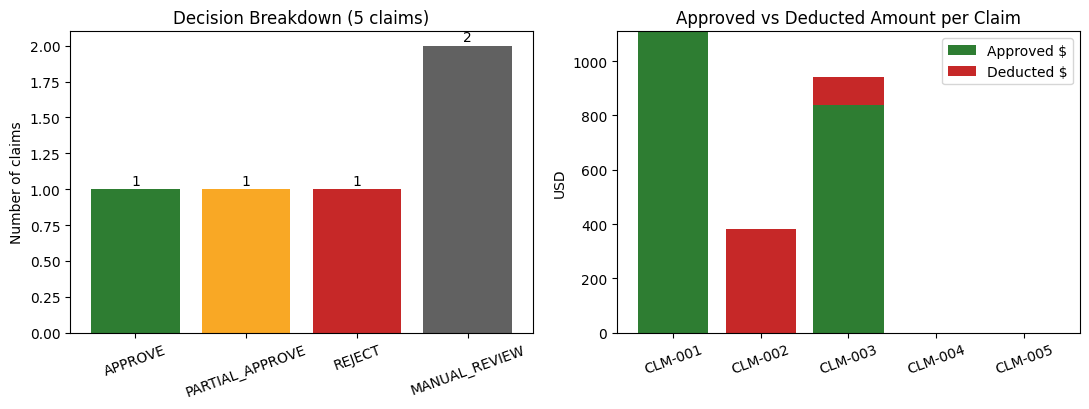

Saved dashboard screenshot -> UI_SS_1.png


In [10]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# --- Decision breakdown ---
decision_counts = df["decision"].value_counts().reindex(
    ["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"], fill_value=0)
colors = {"APPROVE": "#2e7d32", "PARTIAL_APPROVE": "#f9a825", "REJECT": "#c62828", "MANUAL_REVIEW": "#616161"}
axes[0].bar(decision_counts.index, decision_counts.values,
            color=[colors[d] for d in decision_counts.index])
axes[0].set_title("Decision Breakdown (5 claims)")
axes[0].set_ylabel("Number of claims")
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(decision_counts.values):
    axes[0].text(i, v + 0.03, str(v), ha="center")

# --- Approved vs deducted amounts per claim ---
approved = [r["approved_amount"] or 0 for r in results]
deducted = [r["deducted_amount"] or 0 for r in results]
ids = [r["claim_id"] for r in results]
x = range(len(ids))
axes[1].bar(x, approved, label="Approved $", color="#2e7d32")
axes[1].bar(x, deducted, bottom=approved, label="Deducted $", color="#c62828")
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(ids, rotation=20)
axes[1].set_title("Approved vs Deducted Amount per Claim")
axes[1].set_ylabel("USD")
axes[1].legend()

plt.tight_layout()
plt.savefig("UI_SS_1.png", dpi=150)
plt.show()
print("Saved dashboard screenshot -> UI_SS_1.png")


## 6. Final Structured Output (required deliverable — last code cell)

In [11]:

final_output = json.dumps(results, indent=2)
print(final_output)


[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-02",
      "POL-RCT-01"
    ],
    "confidence": 0.92,
    "explanation": "Claim CLM-001 is fully policy-compliant (per policy POL-APR-02, POL-RCT-01); approving the full $1110.00.",
    "tools_used": [
      "timeliness_check",
      "receipt_completeness_check",
      "per_diem_limit_checker",
      "duplicate_detector",
      "approval_threshold_check",
      "llm_explain[local-simulated]",
      "output_validator"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-01",
      "POL-CAT-02",
      "POL-RCT-01"
    ],
    "confidence": 0.92,
    "explanation": "Claim CLM-002 contains only non-reimbursable items (flagged line items: ineligible_category; per policy POL-APR-01, PO

## Design Notes & Reasoning

**Architecture choice — deterministic tools + LLM-as-orchestrator/explainer, not LLM-as-calculator.**
Reimbursement math (per-diem caps, thresholds, receipt rules) is compliance-critical and must be
100% reproducible and auditable, so it's implemented as plain Python tools with no LLM in the
numeric path. The LLM (or its local simulated fallback) is used exactly where GenAI adds value:
deciding *when* Manual Review applies conceptually, and turning structured tool output into a
clear, grounded, human-readable explanation and confidence score. This also means the notebook
runs identically, for free, whether or not the reviewer has an API key configured — an important
trade-off for a timeboxed take-home that will be run on someone else's machine.

**Why so much routes to Manual Review.** The policy explicitly says "prefer Manual Review over
forcing a decision" for: late submissions, missing required receipts, business/first-class
airfare, possible duplicates, and totals above the director tier. I treated each of these as an
independent, OR-combined trigger — any single one is sufficient — rather than trying to net them
against each other. In a real reimbursement system, false auto-approvals are far more costly than
an extra human check, so the agent is deliberately conservative and never "averages away" a
red flag. `output_validator` provides a second, independent safety net: any object that fails the
required schema is force-downgraded to `MANUAL_REVIEW` with confidence 0 rather than emitted as-is.

**Tool granularity.** Five focused tools (receipts, per-diem, duplicates, thresholds, output
validation) plus policy lookup, each independently testable and each returning structured
(not free-text) results, so the orchestrator's combination logic stays simple, deterministic, and
easy to unit-test — over-engineering (e.g. a full multi-agent framework, a vector DB for 15 policy
rules, a database-backed duplicate ledger) was deliberately avoided given the 2–3 day scope.

**Assumptions & simplifications.**
- All 5 claims are pre-loaded as embedded data, exactly as given in Appendix B (per the assignment
  instruction not to invent a claim set); the same `run_agent_on_claim` function works unchanged on
  any new JSON/CSV/API-submitted claim following the same shape.
- Meals/ground-transport per-diem caps are applied to the claim's *aggregate* line amount using the
  stated day count (the sample claims report meals as one aggregated line rather than per-day lines).
- `duplicate_detector` uses a simple in-memory signature (employee + trip dates + total) for this run;
  a production version would check against a persistent claims database and use fuzzier matching.
- Confidence scores are heuristic (derived from decision type and number of flags raised), not a
  calibrated model output — a real system would want a properly calibrated confidence estimator.
- No PII beyond the mock names given in the assignment; nothing else was invented.

**What I'd improve next.**
- Real function-calling (OpenAI/Anthropic tool-use API) so the LLM actively chooses tool order at
  runtime instead of following a fixed pipeline — the current fixed order is a reasonable, auditable
  default for 6 tools, but a function-calling loop would generalize better as more tools are added.
- A persistent audit-trail store (append the `tool_trace` per claim to a log/DB) for compliance review.
- Basic automated test cases (pytest) asserting each tool's output against hand-computed expectations
  for a few synthetic edge cases (e.g., exactly-at-cap amounts, zero-amount lines).
- A small policy-exception workflow so Manual Review outcomes can be captured and fed back to refine
  the routing rules over time.

## Assumptions and Limitations (summary)
- Prototype scope only — not production-hardened (no auth, no persistent storage, no concurrency handling).
- LLM explanation layer falls back to a deterministic local template when no API key is present; this
  keeps the notebook 100% runnable for grading, but a live LLM call (shown in the code path) is the
  intended production behavior.
- Policy is the mock policy given in the assignment (Appendix A) only; no external policy documents were used.
